# Advanced Analytics and Risk Metrics

This notebook performs advanced mutual fund analytics including Value at Risk (VaR), Conditional Value at Risk (CVaR), Rolling Sharpe Ratio, Investor Cohort Analysis, SIP Continuity Analysis, Fund Recommendation System, and Sector Concentration Analysis.

## Imports

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("default")

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Data

In [10]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav_history = pd.read_csv(
    "../data/processed/nav_history_clean.csv"
)

scheme_perf = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print("All Files Loaded Successfully")

All Files Loaded Successfully


## Date Conversion

In [12]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

portfolio["portfolio_date"] = pd.to_datetime(
    portfolio["portfolio_date"]
)

print("Date Conversion Complete")

Date Conversion Complete


## Daily Returns

In [13]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (

    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()

)

daily_returns = nav_history.dropna()

print(
    daily_returns["daily_return"]
    .describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


## Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

### VaR & CVaR Calculation

In [14]:
var_cvar_results = []

for scheme in daily_returns["amfi_code"].unique():

    fund_returns = daily_returns[
        daily_returns["amfi_code"] == scheme
    ]["daily_return"]

    # Historical VaR (95%)
    var_95 = np.percentile(
        fund_returns,
        5
    )

    # CVaR
    cvar_95 = fund_returns[
        fund_returns <= var_95
    ].mean()

    var_cvar_results.append(
        [
            scheme,
            var_95,
            cvar_95
        ]
    )

var_cvar_df = pd.DataFrame(
    var_cvar_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


### Save Deliverable

In [15]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully")

var_cvar_report.csv saved successfully


### Highest Risk Funds

In [16]:
highest_risk = var_cvar_df.sort_values(
    by="VaR_95"
)

highest_risk.head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


### Insight 1

Funds with the most negative VaR values exhibit higher downside risk and are more vulnerable to extreme market movements.

## Rolling 90-Day Sharpe Ratio Analysis

In [17]:
top5_funds = (
    scheme_perf
    .sort_values(
        by="sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

top5_funds

[120507, 120844, 101208, 100025, 119120]

### Rolling Sharpe Calculation

In [18]:
rolling_sharpe_df = pd.DataFrame()

for fund in top5_funds:

    temp = daily_returns[
        daily_returns["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values(
        "date"
    )

    temp["rolling_sharpe"] = (

        temp["daily_return"]
        .rolling(90)
        .mean()

        /

        temp["daily_return"]
        .rolling(90)
        .std()

    ) * np.sqrt(252)

    temp["amfi_code"] = fund

    rolling_sharpe_df = pd.concat(
        [
            rolling_sharpe_df,
            temp
        ]
    )

print("Rolling Sharpe Calculated")

Rolling Sharpe Calculated


### Rolling Sharpe Chart

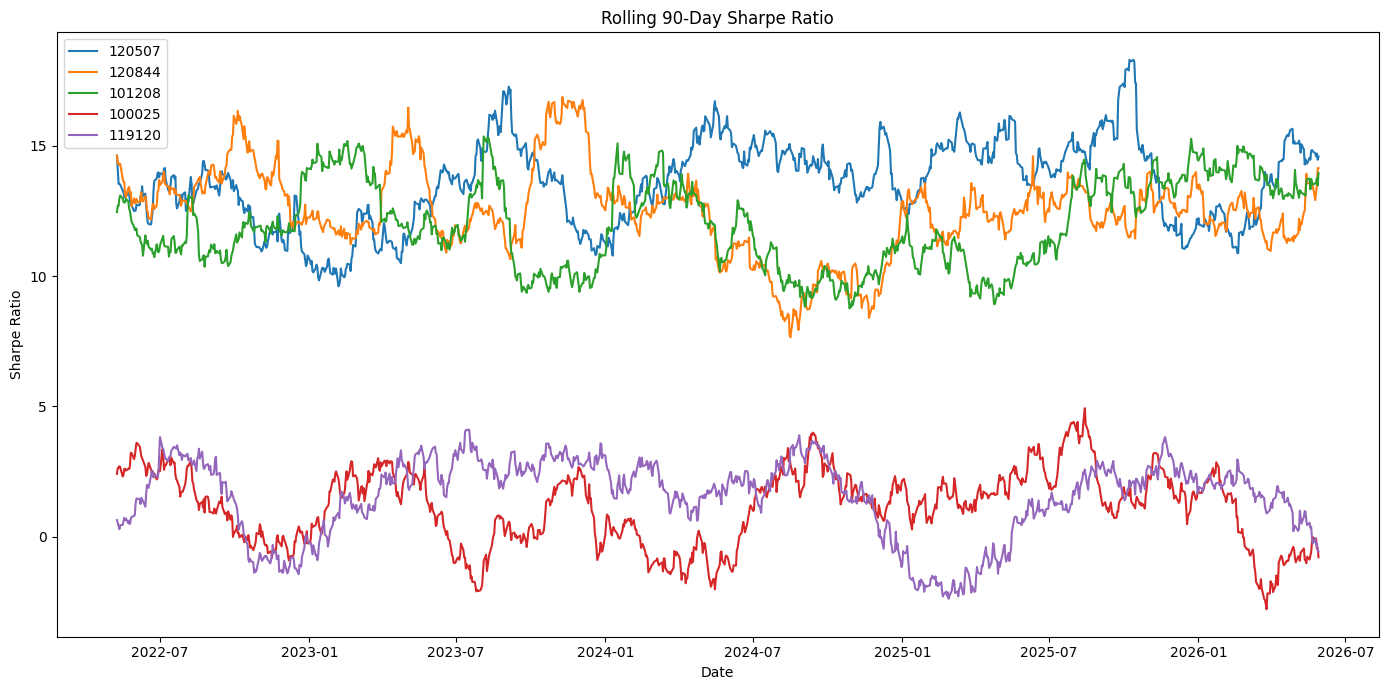

In [19]:
plt.figure(figsize=(14,7))

for fund in top5_funds:

    temp = rolling_sharpe_df[
        rolling_sharpe_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 2

Rolling Sharpe Ratio highlights how risk-adjusted performance changes over time. Funds with consistently higher rolling Sharpe values demonstrate more stable performance.

## Investor Cohort Analysis

### Cohort Year

In [20]:
transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")
    ["transaction_date"]
    .transform("min")
    .dt.year
)

transactions[
    [
        "investor_id",
        "cohort_year"
    ]
].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


### Cohort Metrics

In [21]:
cohort_analysis = (

    transactions

    .groupby("cohort_year")

    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),

        total_invested=(
            "amount_inr",
            "sum"
        ),

        investors=(
            "investor_id",
            "nunique"
        )
    )

    .reset_index()

)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


### Top Fund Preference by Cohort

In [42]:
top_fund_preference = (

    transactions

    .groupby(
        ["cohort_year", "amfi_code"]
    )

    .size()

    .reset_index(name="txn_count")

)

top_fund_preference = (

    top_fund_preference

    .sort_values(
        ["cohort_year", "txn_count"],
        ascending=[True, False]
    )

    .groupby("cohort_year")

    .head(1)

)

top_fund_preference

,cohort_year,amfi_code,txn_count
35,2024,148568,874
62,2025,119599,12


### Insight 3

Investor cohorts entering in different years exhibit varying investment behaviour, with recent cohorts generally contributing higher SIP investments.

## SIP Continuity Analysis

### SIP Transactions Only

In [43]:
sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip_txn = sip_txn.sort_values(
    ["investor_id", "transaction_date"]
)

print("Total SIP Transactions:")
print(len(sip_txn))

sip_txn.head()

Total SIP Transactions:
19716


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,kyc_valid,cohort_year
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,True,2024
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,True,2024
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,True,2024
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,True,2024
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,True,2024


### Gap Between SIPs

In [44]:
sip_txn["gap_days"] = (

    sip_txn

    .groupby("investor_id")

    ["transaction_date"]

    .diff()

    .dt.days

)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,kyc_valid,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,True,2024,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,True,2024,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,True,2024,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,True,2024,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,True,2024,238.0


### Investor Continuity

In [45]:
sip_continuity = (

    sip_txn

    .groupby("investor_id")

    .agg(
        sip_count=(
            "transaction_date",
            "count"
        ),

        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )

    .reset_index()

)

sip_continuity = sip_continuity[
    sip_continuity["sip_count"] >= 6
]

sip_continuity["status"] = np.where(

    sip_continuity["avg_gap_days"] > 35,

    "At Risk",

    "Healthy"

)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


### Continuity Summary

In [46]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

### Insight 4

The majority of investors are classified as At Risk, indicating irregular SIP contribution patterns. Only a small percentage of investors maintain consistent SIP continuity with average gaps below 35 days.

## Fund Recommendation System

### Recommender Function

In [47]:
def recommend_funds(risk_appetite):

    mapping = {
        "Low": ["Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }

    selected_grades = mapping.get(
        risk_appetite,
        ["Moderate"]
    )

    recommendations = (

        scheme_perf[
            scheme_perf["risk_grade"]
            .isin(selected_grades)
        ]

        .sort_values(
            by="sharpe_ratio",
            ascending=False
        )

        .head(3)

        [
            [
                "scheme_name",
                "fund_house",
                "risk_grade",
                "sharpe_ratio",
                "return_3yr_pct"
            ]
        ]

    )

    return recommendations

### Test Recommender

In [48]:
recommend_funds("Low")

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Low,5.14,5.14


### Moderate Risk

In [49]:
recommend_funds("Moderate")

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Moderate,1.03,14.41


### High Risk

In [50]:
recommend_funds("High")

,scheme_name,fund_house,risk_grade,sharpe_ratio,return_3yr_pct
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,High,0.96,18.23
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.95,18.08
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,0.94,23.39


## Sector Concentration Analysis (HHI)

### HHI Calculation

In [51]:
portfolio["weight_sq"] = (
    portfolio["weight_pct"] / 100
) ** 2

hhi_df = (

    portfolio

    .groupby("amfi_code")

    ["weight_sq"]

    .sum()

    .reset_index()

)

hhi_df.columns = [
    "amfi_code",
    "HHI"
]

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


### HHI Ranking

#### Top HHI Funds

In [52]:
hhi_df = hhi_df.sort_values(
    by="HHI",
    ascending=False
)

hhi_df.head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


### Portfolio Concentration Chart

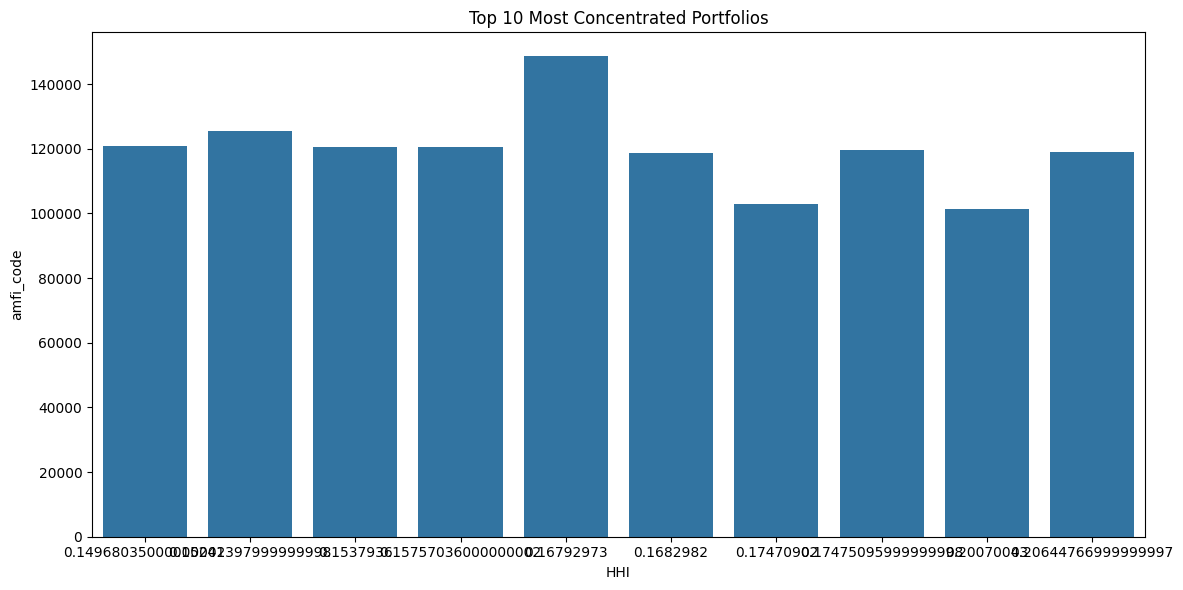

In [53]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=hhi_df.head(10),
    x="HHI",
    y="amfi_code"
)

plt.title(
    "Top 10 Most Concentrated Portfolios"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/hhi_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### HHI Report Export

In [54]:
hhi_df.to_csv(
    "../reports/hhi_concentration_report.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


### Insight 5

Funds with higher HHI scores exhibit greater portfolio concentration and are more dependent on the performance of a smaller number of holdings. Lower HHI values indicate better diversification across sectors and securities.

# Advanced Analytics Summary

## Key Findings

### 1. Value at Risk (VaR) and CVaR
Funds with highly negative VaR and CVaR values demonstrate greater downside exposure during adverse market conditions.

### 2. Rolling Sharpe Ratio
Risk-adjusted performance changes over time, with some funds consistently maintaining superior Sharpe ratios over rolling periods.

### 3. Investor Cohort Behaviour
Different investor cohorts exhibit distinct investment patterns, with certain cohorts contributing significantly higher total investments and average SIP amounts.

### 4. SIP Continuity Analysis
A large proportion of investors were identified as At Risk due to average SIP gaps exceeding 35 days, indicating potential discontinuation risk.

### 5. Portfolio Concentration
HHI analysis reveals varying levels of portfolio concentration across funds, highlighting differences in diversification strategies.

## Conclusion

Advanced analytics provide deeper insights into fund risk, investor behaviour, portfolio concentration, and risk-adjusted performance. These metrics support better investment decision-making and fund selection.